### Welcome! This notebook will help you get started with geospatial analysis using geopandas.

In [1]:
# install geopandas if you haven't already
%pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 38.6 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 59.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
Note: you may need to restart the kernel to use updated packages.


In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt


Let's begin with reading and viewing the first dataset, the USDA Food Deserts shapefile. These GIS files contain data and metadata regarding all food desert census tracts in the state of Georgia. 

Geopandas uses very similar syntax to pandas for most functions, though there are some differences to be aware of. For example, geopandas exclusively uses the function read_file() rather than stating the file type.

In [2]:
food_deserts = gpd.read_file("lila_halfmi_census.shp")
food_deserts.head()

,CnssTrc,State,County,LILAT_1A1,LILAT_A,LILAT_1A2,LILAT_V,PvrtyRt,MdnFmlI,LAhlf10,...,tract,STATEFP,COUNTYF,TRACTCE,BLOCKCE,BLOCKID,PARTFLG,HOUSING,POP10,geometry
0,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1060,131210006001060,N,329,342,"POLYGON ((-84.40747 33.78225, -84.40748 33.781..."
1,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1054,131210006001054,N,7,20,"POLYGON ((-84.40419 33.78154, -84.4043 33.7817..."
2,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1053,131210006001053,N,23,26,"POLYGON ((-84.40263 33.78153, -84.40273 33.781..."
3,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1074,131210006001074,N,0,0,"POLYGON ((-84.41343 33.78159, -84.41341 33.781..."
4,13121000600,Georgia,Fulton County,0.0,1.0,0.0,1.0,43.86073,96850,1.0,...,000600,13,121,000600,1070,131210006001070,N,0,0,"POLYGON ((-84.41069 33.78062, -84.41243 33.780..."


As you can see above, geopandas "GeoDataFrames" can still use many standard functions of regular pandas DataFrames, such as .head(), .shape, .summarise(), etc.

<Axes: >

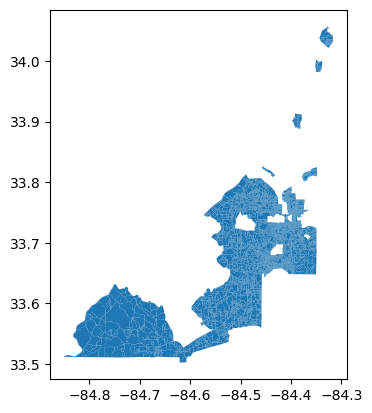

In [3]:
food_deserts.plot()

One important aspect of working with geospatial data is understanding which coordinate reference system (CRS) each dataset uses. This is similar to working with lengths in miles or kilometers or temperatures in Celsius or Fahrenheit; if you try to compare two datasets that were created using different measurement systems, the results will be nonsensical.

In [4]:
food_deserts.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

This CRS epsg:4326 is the most common CRS in all of GIS. This is named the "World Geodetic Standard" (WGS) because it is the global standard system to use. This coordinate reference system uses degrees latitude and longitude, though there is also a metric counterpart to the same world standard that can be used when more precise mathematical calculations are needed, epsg:3857

Now we will load another dataset, this time from excel. Because excel cannot store GIS metadata in the same way as shapefiles, we will first load the dataset as a regular DataFrame, then convert it to a GeoDataFrame.

In [5]:
biz_data = pd.read_excel("Atlanta_Business_License_Records_2025.xlsx")
biz_data.head()

,license_number,company_name,company_dba,license_classification,issued_date,naics_code,naics_name,predirection,address_line1,address_line2,...,city,state,postal_code,address_concat,address_api,longitude,latitude,disinvested_neighborhood,council_district,npu
0,GBL-0121-00257,H & H Interiors LLC,NaN,Other Services except Public Administration,2025-01-07 13:21:16.143,541410.0,Interior Design Services,NE,2652 Forrest,NaN,...,Atlanta,GA,NaN,2652 Forrest nan WAY Atlanta GA nan,"2652 Forrest Way NE, Atlanta, Georgia, 30305",-84.379893,33.827640,False,7,B
1,GBL-0121-00258,One Lion Studios LLC,NaN,Other Services except Public Administration,2025-02-16 18:39:21.153,541840.0,Media Representatives,NaN,3343 Peachtree Rd NE,NaN,...,Atlanta,GA,30326,3343 Peachtree Rd NE nan nan Atlanta GA 30326,"3343 Peachtree Rd NE, Atlanta, Georgia, 30326",-84.367109,33.846760,False,7,B
2,GBL-0121-00272,Destingkt Designs LLC,NaN,Other Services except Public Administration,2025-03-04 23:04:53.980,541410.0,Interior Design Services,NaN,931,PONCE DE LEON,...,Atlanta,GA,NaN,931 PONCE DE LEON AVE Atlanta GA nan,"931 Ponce de Leon Ave NE, Atlanta, Georgia, 30306",-84.356939,33.773524,False,2,N
3,GBL-0121-00274,Mac Cigars LLC,J's Cigars,Retail Trade,2025-02-25 23:09:11.497,453991.0,Tobacco Stores,NaN,2072,Defoors Ferry,...,Atlanta,GA,30318,2072 Defoors Ferry RD Atlanta GA 30318,"2072 Defoors Ferry Rd NW, Atlanta, Georgia, 30318",-84.426318,33.812071,False,9,D
4,GBL-0121-00283,Essence of She Day Spa Salon,NaN,Other Services except Public Administration,2025-01-09 19:04:30.857,812112.0,Beauty Salons,NaN,144,MORELAND,...,ATLANTA,GA,30307,144 MORELAND AVE ATLANTA GA 30307,"144 Moreland Ave NE, Atlanta, Georgia, 30307",-84.349501,33.756604,False,5,N


As you can see, the latitude and longitude values are stored in columns for every business address in the dataset. This enables you to create coordinates from those columns, using the geopandas function points_from_xy()

In [6]:
biz_geo = gpd.GeoDataFrame(biz_data, geometry = gpd.points_from_xy(biz_data['longitude'], biz_data['latitude']), crs = 'epsg:4326')

In this one line, three important things are happening:
1. We coerce the dataframe to a geodataframe using geopandas
2. The latitude and longitude columns are converted to coordinate points using points_from_xy()
3. Because there are no metadata files geopandas can use to determine the CRS, you must manually state which CRS was used in these coordinates. In this case, we know that the datset was created using a geocoding API that returns coordinates in epsg:4326, which is extremely common. If you ever don't know which CRS was used for a dataset you want to work with, there are ways to troubleshoot, but it's best to download geospatial data as shapefiles or geojson whenever possible to avoid the issue.

<Axes: >

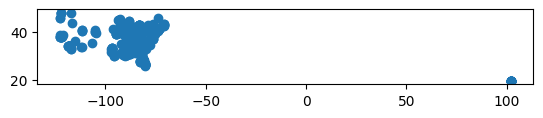

In [7]:
biz_geo.plot()

<Axes: >

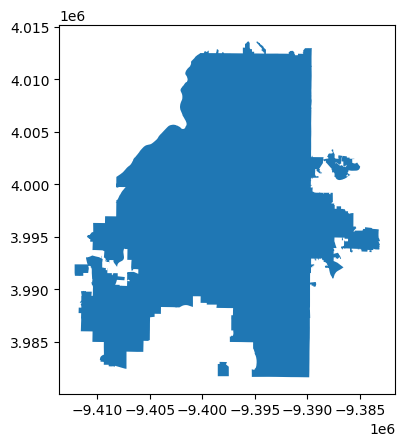

In [8]:
atl = gpd.read_file("Atlanta_City_Limits.shp")
atl.plot()

In [9]:
atl.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
biz_geo = biz_geo.to_crs(crs = 'epsg:3857')

In [11]:
biz_geo.crs == atl.crs

True

In [12]:
biz_check = gpd.sjoin(biz_geo, atl, how = 'left', predicate = 'within')
atl_biz = biz_check.loc[(biz_check['NAME'] == 'Atlanta')]
atl_biz.shape

(17104, 43)

<Axes: >

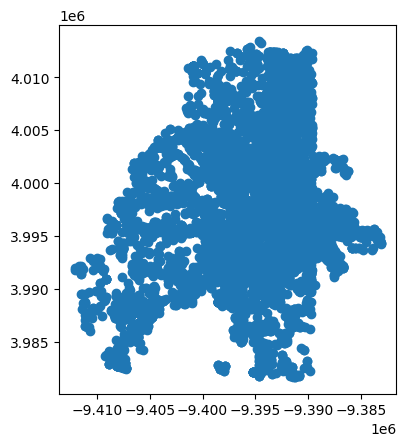

In [13]:
atl_biz.plot()

<Axes: >

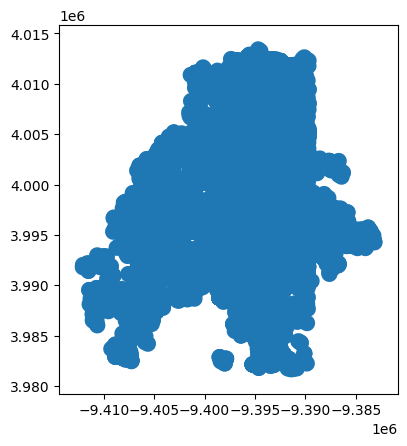

In [17]:
# buffer example
biz_halfmi = atl_biz.geometry.buffer(804.5, resolution = 20, cap_style = 'round')
biz_halfmi.plot()